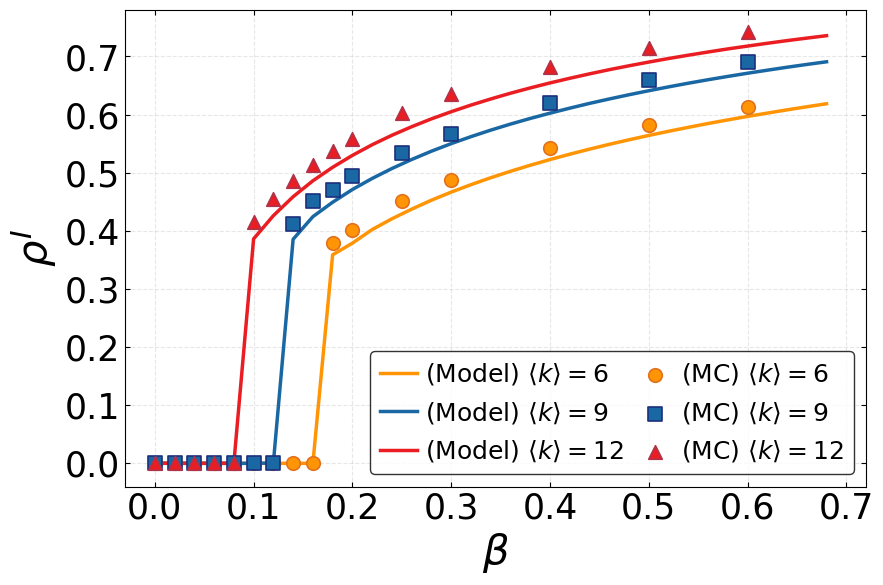

In [1]:
#!/usr/bin/env python3
# plot_rho_vs_beta_styled.py
"""
绘制 ρ(β) 对比图，三条平均度曲线：
 - MMCA: 实线
 - MC: 空心散点（误差棒）
使用 enumerate(zip(...)) 写法循环定义 label、颜色、marker。
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------- 文件路径与参数 --------------------
OUT_MMCA = "./out_mmca"
OUT_MC = "./out_mc"

KAPPAS = [6, 9, 12]  # 三条曲线
labels = [r"$\langle k \rangle=6$", r"$\langle k \rangle=9$", r"$\langle k \rangle=12$"]
# colors = ['#4E9980', '#526BA4', '#E93A32']   # 自定义颜色（绿、蓝、红）
colors = ["#ff9505", "#1A68A3", '#EA1D22'] 
facecolors = ["#e2711d", "#1C2F7C", "#AF334A"]   
markers = ['o', 's', '^']                    # MC 散点标记

SAVE_FIG = True
FIG_NAME = "rho_vs_beta_styled.pdf"

# -------------------- 绘图 --------------------
plt.figure(figsize=(9, 6))

for i, (k, label, color, marker) in enumerate(zip(KAPPAS, labels, colors, markers)):
    fn_mmca = os.path.join(OUT_MMCA, f"mmca_kappa{k}_summary.csv")

    df_mmca = pd.read_csv(fn_mmca)

    beta = df_mmca['beta'].to_numpy()
    rho_mmca = df_mmca['mean_rho'].to_numpy()

    # MMCA：实线
    plt.plot(beta, rho_mmca, color=color, linewidth=2.5,
             label=f"(Model) {label}")
    
for i, (k, label, color, facecolor, marker) in enumerate(zip(KAPPAS, labels, colors, facecolors, markers)):
    fn_mc = os.path.join(OUT_MC, f"mc_kappa{k}_summary.csv")

    df_mc = pd.read_csv(fn_mc)

    rho_mc = df_mc['mean_rho'].to_numpy()
    beta_mc = df_mc['beta'].to_numpy()
    std_mc = df_mc['std_rho'].to_numpy()

    # MC：空心点 + 误差棒
    plt.scatter(beta_mc, rho_mc, linewidths=1.2, zorder=3, edgecolor=facecolor,
                 color=color, marker=marker, s = 95,
                 label=fr"(MC) {label}")
 
 
# -------------------- 美化 --------------------
plt.xlabel(r"$\beta$", fontsize=30)
plt.ylabel(r"$\rho^I$", fontsize=30)

plt.xlim(-0.03, 0.72)  # 设置x轴范围
plt.ylim(-0.04, 0.78)   # 设置y轴范围
plt.xticks(fontsize='25')
plt.yticks(fontsize='25')
# plt.title(r"Comparison of $\rho^*$ vs $\beta$ (MMCA lines, MC points)", fontsize=14)
plt.grid(alpha=0.3, linestyle='--', linewidth=0.8)

plt.tight_layout()

legend = plt.legend(
    loc='lower right',
    fontsize='18',
    handletextpad=0.3,    # 图标与文本的间距
    # columnspacing=1,      # 列间距（多列时有效）
    borderpad=0.4,          # 图例内边距
    ncol=2,              # 分两列
    handlelength=1.5,    # 统一图标宽度
    columnspacing=0.5,     # 缩小列间距（默认2.0）
)

# 启用四面刻度
plt.tick_params(
    axis='both',      # 同时控制 x 和 y 轴
    which='both',     # 同时控制主刻度和次刻度
    top=True,         # 显示顶部刻度
    right=True,       # 显示右侧刻度
    labeltop=False,   # 不显示顶部刻度标签（避免重叠）
    labelright=False,  # 不显示右侧刻度标签（避免重叠）
    direction='in',   # 刻度朝内
)



legend.get_frame().set_edgecolor('black')
legend.get_frame().set_linewidth(1)

# -------------------- 保存与显示 --------------------
# if SAVE_FIG:
#     plt.savefig(FIG_NAME, bbox_inches='tight', dpi=300)
#     print(f"✅ Saved figure to {FIG_NAME}")
plt.savefig('test1_1.pdf', bbox_inches='tight', dpi=300)
plt.savefig('test1_1.jpg', bbox_inches='tight', dpi=300)
plt.show()


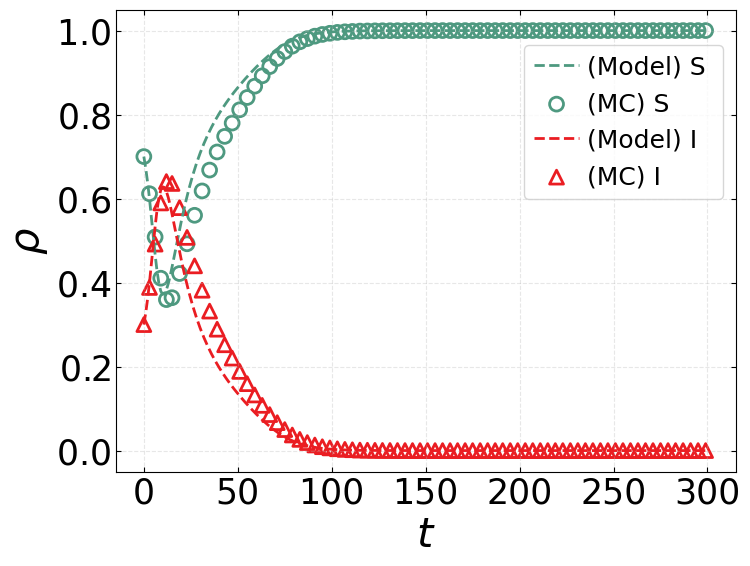

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 读取 MC 数据
mean_df_mc = pd.read_csv("./out_mc/rho_mean_mc_comparison.csv")
ts_mc = mean_df_mc['time'].values
mean_rho_mc_1 = mean_df_mc['mean_rho_mc_1'].values
mean_rho_mc_2 = mean_df_mc['mean_rho_mc_2'].values

# Susceptible fractions
mean_S_mc_1 = 1 - mean_rho_mc_1
mean_S_mc_2 = 1 - mean_rho_mc_2

# 读取 MMCA 数据
mean_df_mmca = pd.read_csv("./out_mmca/rho_mean_mmca_comparison.csv")
ts_mmca = mean_df_mmca['time'].values
mean_rho_mmca_1 = mean_df_mmca['mean_rho_mmca_1'].values
mean_rho_mmca_2 = mean_df_mmca['mean_rho_mmca_2'].values


# Susceptible fractions
mean_S_mmca_1 = 1 - mean_rho_mmca_1
mean_S_mmca_2 = 1 - mean_rho_mmca_2

# -------------------- 绘图 --------------------
plt.figure(figsize=(8,6))

import numpy as np

# 前x个点：正常取所有点
indices_first = np.arange(0, min(15, len(ts_mc)), 3)

# x个点之后：每隔3个取一个
indices_second = np.arange(15, len(ts_mc), 4)

# 合并索引
indices = np.concatenate([indices_first, indices_second])

plt.plot(ts_mmca, mean_S_mmca_1,
         linestyle='--',color='#4E9980', label=f'(Model) S ',
            alpha=1, linewidth=2)

plt.scatter(ts_mc[indices], mean_S_mc_1[indices],  
            marker='o', color='#4E9980', label=f'(MC) S',facecolors='none', 
            edgecolors='#4E9980', alpha=1, s=100, linewidths=2)

plt.plot(ts_mmca, mean_rho_mmca_1,
         linestyle='--',color='#EA1D22', label=f'(Model) I ',
            alpha=1, linewidth=2)

plt.scatter(ts_mc[indices], mean_rho_mc_1[indices],  
            marker='^', color='#EA1D22', label=f'(MC) I',facecolors='none', 
            edgecolors='#EA1D22', alpha=1, s=100, linewidths=2)

# 启用四面刻度
plt.tick_params(
    axis='both',      # 同时控制 x 和 y 轴
    which='both',     # 同时控制主刻度和次刻度
    top=True,         # 显示顶部刻度
    right=True,       # 显示右侧刻度
    labeltop=False,   # 不显示顶部刻度标签（避免重叠）
    labelright=False,  # 不显示右侧刻度标签（避免重叠）
    direction='in',   # 刻度朝内
)


legend = plt.legend(
    loc='upper right',
    bbox_to_anchor=(1, 0.95),
    fontsize='18',
    handletextpad=0.3,    # 图标与文本的间距
    #columnspacing=1,      # 列间距（多列时有效）
    borderpad=0.4,          # 图例内边距
    # ncol=2,              # 分两列
    handlelength=1.8,    # 统一图标宽度
    columnspacing=0.5,     # 缩小列间距（默认2.0）
)
plt.xlabel(r'$t$',fontsize='30')
plt.ylabel(r'$\rho$',fontsize='30')
plt.xticks(fontsize='25')
plt.yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0], 
           [r'$0.0$',r'$0.2$',r'$0.4$', r'$0.6$', r'$0.8$', r'$1.0$'], fontsize='25')
plt.grid(alpha=0.3, linestyle='--', linewidth=0.8)
plt.savefig('test1_2.pdf', bbox_inches='tight', dpi=300)
plt.savefig('test1_2.jpg', bbox_inches='tight', dpi=300)
plt.show()



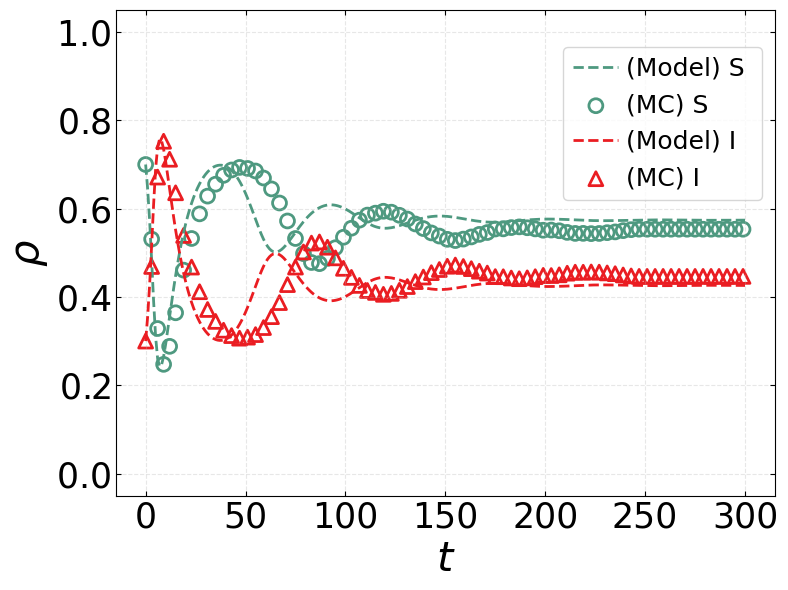

In [3]:
plt.figure(figsize=(8,6))

import numpy as np

# 前x个点：正常取所有点
indices_first = np.arange(0, min(15, len(ts_mc)), 3)

# x个点之后：每隔3个取一个
indices_second = np.arange(15, len(ts_mc), 4)

# 合并索引
indices = np.concatenate([indices_first, indices_second])

plt.plot(ts_mmca, mean_S_mmca_2,
         linestyle='--',color='#4E9980', label=f'(Model) S ',
            alpha=1, linewidth=2)
plt.scatter(ts_mc[indices], mean_S_mc_2[indices],  
            marker='o', color='#4E9980', label=f'(MC) S',facecolors='none', 
            edgecolors='#4E9980', alpha=1, s=100, linewidths=2)

plt.plot(ts_mmca, mean_rho_mmca_2,
         linestyle='--',color='#EA1D22', label=f'(Model) I ',
            alpha=1, linewidth=2)
plt.scatter(ts_mc[indices], mean_rho_mc_2[indices],  
            marker='^', color='#EA1D22', label=f'(MC) I',facecolors='none', 
            edgecolors='#EA1D22', alpha=1, s=100, linewidths=2)

# 启用四面刻度
plt.tick_params(
    axis='both',      # 同时控制 x 和 y 轴
    which='both',     # 同时控制主刻度和次刻度
    top=True,         # 显示顶部刻度
    right=True,       # 显示右侧刻度
    labeltop=False,   # 不显示顶部刻度标签（避免重叠）
    labelright=False,  # 不显示右侧刻度标签（避免重叠）
    direction='in',   # 刻度朝内
)


legend = plt.legend(
    loc='upper right',
    bbox_to_anchor=(1, 0.95),
    fontsize='18',
    handletextpad=0.3,    # 图标与文本的间距
    #columnspacing=1,      # 列间距（多列时有效）
    borderpad=0.4,          # 图例内边距
    # ncol=2,              # 分两列
    handlelength=1.8,    # 统一图标宽度
    columnspacing=0.5,     # 缩小列间距（默认2.0）
)

plt.xlabel(r'$t$',fontsize='30')
plt.ylabel(r'$\rho$',fontsize='30')
plt.xticks(fontsize='25')
plt.yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0], 
           [r'$0.0$',r'$0.2$',r'$0.4$', r'$0.6$', r'$0.8$', r'$1.0$'], fontsize='25')
plt.ylim(-0.05, 1.05)
plt.tight_layout()
plt.grid(alpha=0.3, linestyle='--', linewidth=0.8)
plt.savefig('test1_3.pdf', bbox_inches='tight', dpi=300)
plt.savefig('test1_3.jpg', bbox_inches='tight', dpi=300)
plt.show()